# 解答例：確率的シミュレーションの課題

元Notebook：[32_stochastic_simulation_repeats.ipynb](../32_stochastic_simulation_repeats.ipynb)．

課題と解答，必要な定義だけをまとめた，単独で実行できるNotebookである．

## 課題：実装と検証

1. `repeat_with_fixed_seed(n)` と `repeat_with_different_seeds(n)` を実装し，同じseedで毎回初期化する場合と独立な反復の場合の分散を比較する．
2. `repeat_summary(repeat_counts)` と `plot_running_mean(times)` を実装し，平均・標準偏差・標準誤差・近似95%信頼区間を理論値と比べる．上限の打切りがないことを確認してから完了時間を集計する．
3. `cutoff_summary(horizons)` を実装し，各上限で完了率，完了者だけの平均，上限制限平均を区別する．全員の真の平均 `44/0.72` と同一視しない．
4. 共通の時刻別乱数を2条件に与える `paired_comparison(n)` を実装し，対応差の平均と標準誤差を求める．別々の条件の標準誤差を単純に足さない．
5. 31章の反復結果の表を設計する．初期配置ID，更新seed，条件，観測上限，終了状態，完了時刻，残人数，上限制限時間を保存する．

## 実行に必要な定義

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def check_counts_probability(n_alight, n_board, pass_probability, max_steps):
    if any(not isinstance(n, (int, np.integer)) or n < 0 for n in [n_alight, n_board]):
        raise ValueError('counts must be nonnegative integers')
    if not np.isfinite(pass_probability) or not 0 <= pass_probability <= 1:
        raise ValueError('pass_probability must be in [0, 1]')
    if not isinstance(max_steps, (int, np.integer)) or max_steps < 1:
        raise ValueError('max_steps must be a positive integer')


def simulate_baseline(seed=0, n_alight=24, n_board=20, pass_probability=0.72,
                      max_steps=1000, uniforms=None):
    check_counts_probability(n_alight, n_board, pass_probability, max_steps)
    if uniforms is None:
        uniforms = np.random.default_rng(seed).random(max_steps)
    else:
        uniforms = np.asarray(uniforms, dtype=float)
        if uniforms.shape != (max_steps,) or not np.isfinite(uniforms).all() or np.any((uniforms < 0) | (uniforms >= 1)):
            raise ValueError('uniforms must have max_steps values in [0, 1)')
    remaining_alight, remaining_board = n_alight, n_board
    history = [(0, remaining_alight, remaining_board)]
    time = 0
    while remaining_alight+remaining_board > 0 and time < max_steps:
        success = uniforms[time] < pass_probability
        time += 1
        if success:
            if remaining_alight:
                remaining_alight -= 1
            else:
                remaining_board -= 1
        history.append((time, remaining_alight, remaining_board))
    completed = remaining_alight+remaining_board == 0
    return dict(completion_time=float(time) if completed else np.nan, completed=completed,
                status='completed' if completed else 'cutoff', cutoff=not completed,
                capped_time=float(time), horizon=max_steps, remaining=remaining_alight+remaining_board,
                history=np.asarray(history))


def analytic_moments(total, p):
    check_counts_probability(total, 0, p, 1)
    if total == 0:
        return 0.0, 0.0
    if p == 0:
        return np.inf, np.nan
    return total/p, total*(1-p)/p**2


def mean_summary(values):
    sample = np.asarray(values, dtype=float)
    if sample.ndim != 1 or sample.size < 2 or not np.isfinite(sample).all():
        raise ValueError('need at least two finite observations; do not silently drop censored values')
    n = sample.size
    sd = sample.std(ddof=1)
    se = sd/np.sqrt(n)
    margin = stats.t.ppf(0.975, n-1)*se
    return dict(n=n, mean=sample.mean(), median=np.median(sample), std=sd, se=se,
                q25=np.quantile(sample, 0.25), q75=np.quantile(sample, 0.75),
                ci_low=sample.mean()-margin, ci_high=sample.mean()+margin)


def wilson_interval(successes, n, confidence=0.95):
    if not isinstance(n, (int, np.integer)) or not isinstance(successes, (int, np.integer)) or n < 1 or not 0 <= successes <= n:
        raise ValueError('invalid binomial counts')
    if not 0 < confidence < 1:
        raise ValueError('confidence must be in (0, 1)')
    z = stats.norm.ppf((1+confidence)/2)
    phat = successes/n
    denominator = 1+z*z/n
    center = (phat+z*z/(2*n))/denominator
    half = z*np.sqrt(phat*(1-phat)/n+z*z/(4*n*n))/denominator
    low = 0.0 if successes == 0 else max(0.0, center-half)
    high = 1.0 if successes == n else min(1.0, center+half)
    return low, high


def repeat_trials(n=200, master_seed=2026, **kwargs):
    if not isinstance(n, (int, np.integer)) or n < 1:
        raise ValueError('n must be a positive integer')
    streams = np.random.SeedSequence(master_seed).spawn(n)
    rows = []
    for replicate, seed in enumerate(streams):
        result = simulate_baseline(seed=seed, **kwargs)
        rows.append(dict(replicate=replicate, master_seed=master_seed,
                         **{key: result[key] for key in ['completion_time', 'capped_time', 'completed',
                                                        'status', 'cutoff', 'horizon', 'remaining']}))
    return pd.DataFrame(rows)

## 解答例：反復と平均の不確かさ

fixed-seed variance: 0.0
independent-trial variance: 22.624081632653063


,n,mean,median,std,se,q25,q75,ci_low,ci_high
0,10,62.700000,61.5,3.917199,1.238727,61.00,64.0,59.897805,65.502195
1,30,60.866667,61.0,4.576803,0.835606,57.25,64.0,59.157660,62.575673
2,100,60.640000,61.0,4.452941,0.445294,58.00,63.0,59.756440,61.523560
3,400,61.347500,61.0,4.604862,0.230243,58.00,64.0,60.894859,61.800141


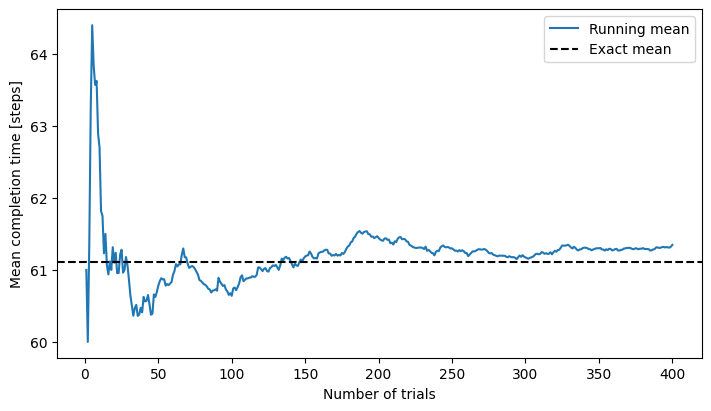

In [2]:
def repeat_with_fixed_seed(n):
    return np.array([simulate_baseline(seed=0)['completion_time'] for _ in range(n)])


def repeat_with_different_seeds(n):
    raw = repeat_trials(n=n)
    if not raw['completed'].all():
        raise ValueError('completion times are censored')
    return raw['completion_time'].to_numpy()


def repeat_summary(repeat_counts):
    counts = list(repeat_counts)
    sample = repeat_with_different_seeds(max(counts))
    return pd.DataFrame([mean_summary(sample[:n]) for n in counts])


def plot_running_mean(times):
    times = np.asarray(times)
    n = np.arange(1, len(times)+1)
    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    ax.plot(n, np.cumsum(times)/n, label='Running mean')
    ax.axhline(44/0.72, linestyle='--', color='black', label='Exact mean')
    ax.set(xlabel='Number of trials', ylabel='Mean completion time [steps]')
    ax.legend()
    return fig


print('fixed-seed variance:', repeat_with_fixed_seed(50).var(ddof=1))
print('independent-trial variance:', repeat_with_different_seeds(50).var(ddof=1))
display(repeat_summary([10, 30, 100, 400]))
plot_running_mean(repeat_with_different_seeds(400))
plt.show()

## 解答例：打切りのある集計

In [3]:
def cutoff_summary(horizons):
    rows = []
    for C in horizons:
        raw = repeat_trials(n=400, max_steps=C)
        low, high = wilson_interval(int(raw['completed'].sum()), len(raw))
        rows.append(dict(C=C, completed_count=int(raw['completed'].sum()),
                         completion_rate=raw['completed'].mean(), ci_low=low, ci_high=high,
                         completed_only_mean=raw['completion_time'].mean(),
                         capped_mean=raw['capped_time'].mean()))
    return pd.DataFrame(rows)


display(cutoff_summary([45, 55, 65, 90]))

,C,completed_count,completion_rate,ci_low,ci_high,completed_only_mean,capped_mean
0,45,0,0.00,0.000000,0.009512,NaN,45.0000
1,55,40,0.10,0.074299,0.133311,53.825000,54.8825
2,65,332,0.83,0.790091,0.863631,59.858434,60.7325
3,90,400,1.00,0.990488,1.000000,61.347500,61.3475


## 解答例：対応差と研究用の記録

In [4]:
def paired_comparison(n):
    rows = []
    for replicate, child in enumerate(np.random.SeedSequence(91).spawn(n)):
        uniforms = np.random.default_rng(child).random(120)
        base = simulate_baseline(pass_probability=0.65, max_steps=120, uniforms=uniforms)
        alt = simulate_baseline(pass_probability=0.8, max_steps=120, uniforms=uniforms)
        rows.append(dict(replicate=replicate, base=base['capped_time'], alt=alt['capped_time'],
                         base_completed=base['completed'], alt_completed=alt['completed']))
    raw = pd.DataFrame(rows)
    raw['difference'] = raw['alt']-raw['base']
    return raw, pd.DataFrame([mean_summary(raw['difference'])])


paired_raw, paired_summary = paired_comparison(400)
display(paired_summary)
columns = ['replicate', 'initial_configuration_id', 'update_seed', 'condition', 'horizon',
           'status', 'completed', 'completion_time', 'remaining', 'capped_time']
research_table = pd.DataFrame(columns=columns)
display(research_table)

,n,mean,median,std,se,q25,q75,ci_low,ci_high
0,400,-12.625,-12.0,4.566894,0.228345,-15.0,-9.0,-13.073909,-12.176091


,replicate,initial_configuration_id,update_seed,condition,horizon,status,completed,completion_time,remaining,capped_time


## 解答例：解釈

同じseedで毎回初期化すると同じ実験の複製になり，分散0は不確かさがないことを意味しない．独立な反復では完了時間の標準偏差自体は消えず，平均の標準誤差が反復数の平方根に反比例して小さくなる．

完了者だけの平均は短い上限ほど選別の影響を受ける．`min(T,C)` の平均は全試行を使えるが，上限を含めた別の評価量であり，無制限の平均ではない．対応比較では反復ごとの `alt-base` を計算してから標準誤差を求める．同じseedだけでは乱数が同じ出来事に対応するとは限らないので，今回は時刻別の配列を共有している．